# Import Library & Konfigurasi Path

In [266]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Konfigurasi ──────────────────────────────────────────────
DATASET_DIR = Path("Dataset")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if (DATASET_DIR / d).is_dir()
])

print("Kelas ditemukan:", CLASS_NAMES)
print("Jumlah kelas   :", len(CLASS_NAMES))

Kelas ditemukan: ['100k', '10k', '20k', '2k', '50k', '5k']
Jumlah kelas   : 6


In [267]:
#=========== Preproessing Parameters ===========
TARGET_CLASS = "100k"    # Ubah menjadi "2k", "5k", "10k", atau "20k"
IMAGE_INDEX = 1         # gambar ke-

TARGET_WIDTH = 256
TARGET_HEIGHT = 256

# Preprocessing

## 1. HSV Masking

In [268]:
def mask_hsv(image_bgr, gray_threshold=25, min_area_ratio=0.01, kernel_size=7):
    if image_bgr is None:
        raise ValueError("Gambar tidak berhasil dibaca.")

    work_img = image_bgr.copy()

    # Konversi ke grayscale
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)

    # Threshold
    _, mask = cv2.threshold(
        gray,
        gray_threshold,
        255,
        cv2.THRESH_BINARY
    )

    # Morphological operations
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (kernel_size, kernel_size)
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Fill holes
    h, w = mask.shape

    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)

    cv2.floodFill(
        flood,
        flood_mask,
        (0, 0),
        255
    )

    flood_inv = cv2.bitwise_not(flood)
    mask = mask | flood_inv

    # Ambil komponen terbesar
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    refined = np.zeros_like(mask)

    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        largest_idx = 1 + np.argmax(areas)
        largest_area = stats[largest_idx, cv2.CC_STAT_AREA]

        min_area = int(min_area_ratio * h * w)

        if largest_area >= min_area:
            refined[labels == largest_idx] = 255
        else:
            refined = mask.copy()
    else:
        refined = mask.copy()

    # Segmentasi
    result = cv2.bitwise_and(
        work_img,
        work_img,
        mask=refined
    )

    return work_img, refined, result

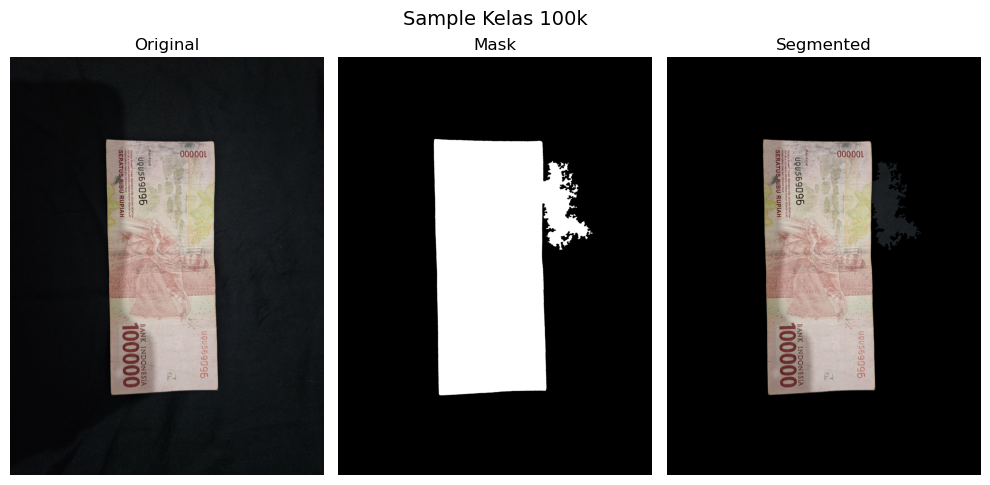

In [269]:
# Folder kelas
class_path = DATASET_DIR / TARGET_CLASS

# Ambil semua file gambar
image_files = sorted([
    f for f in os.listdir(class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
])

if len(image_files) == 0:
    raise ValueError(f"Tidak ada gambar pada folder {TARGET_CLASS}")

# Pilih gambar berdasarkan indeks
sample_image = image_files[IMAGE_INDEX]

img_path = class_path / sample_image

# Baca gambar
img = cv2.imread(str(img_path))

if img is None:
    raise ValueError(f"Gagal membaca gambar:\n{img_path}")

# Jalankan segmentasi
original, mask, segmented = mask_hsv(img)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask")

axes[2].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
axes[2].set_title("Segmented")

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Sample Kelas {TARGET_CLASS}", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Cropping

In [270]:
def crop_to_mask(image_bgr, mask, pad_ratio=0.05):

    coords = cv2.findNonZero(mask)

    if coords is None:
        return image_bgr

    x, y, w, h = cv2.boundingRect(coords)

    h_img, w_img = image_bgr.shape[:2]

    pad = int(max(w, h) * pad_ratio)

    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w + pad, w_img)
    y2 = min(y + h + pad, h_img)

    return image_bgr[y1:y2, x1:x2]

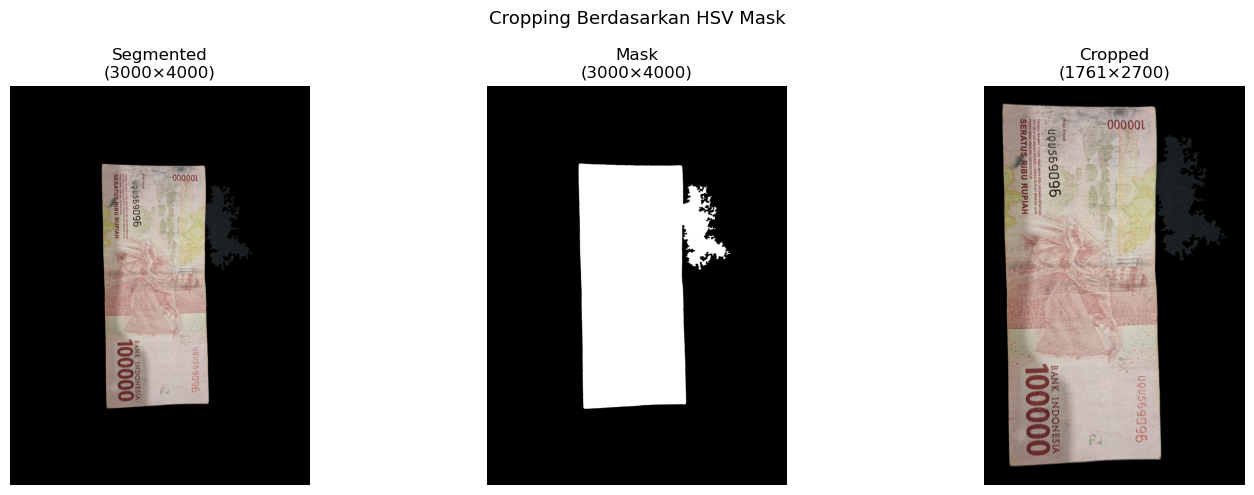

In [271]:
# Hasil crop
cropped = crop_to_mask(segmented, mask)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Segmented
axes[0].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
axes[0].set_title(
    f"Segmented\n({segmented.shape[1]}×{segmented.shape[0]})"
)

# Mask
axes[1].imshow(mask, cmap="gray")
axes[1].set_title(
    f"Mask\n({mask.shape[1]}×{mask.shape[0]})"
)

# Cropped
axes[2].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
axes[2].set_title(
    f"Cropped\n({cropped.shape[1]}×{cropped.shape[0]})"
)

# Hilangkan axis
for ax in axes:
    ax.axis("off")

plt.suptitle("Cropping Berdasarkan HSV Mask", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Resize

In [272]:
def resize(image_bgr, target_width, target_height, fill_value=0):
    h, w = image_bgr.shape[:2]

    # Hitung skala
    scale = min(target_width / w, target_height / h)

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    # Resize
    resized = cv2.resize(
        image_bgr,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    # Buat canvas
    output = np.full(
        (target_height, target_width, 3),
        fill_value,
        dtype=np.uint8
    )

    # Posisi tengah
    x_offset = (target_width - new_w) // 2
    y_offset = (target_height - new_h) // 2

    # Tempel gambar
    output[
        y_offset:y_offset+new_h,
        x_offset:x_offset+new_w
    ] = resized

    return output

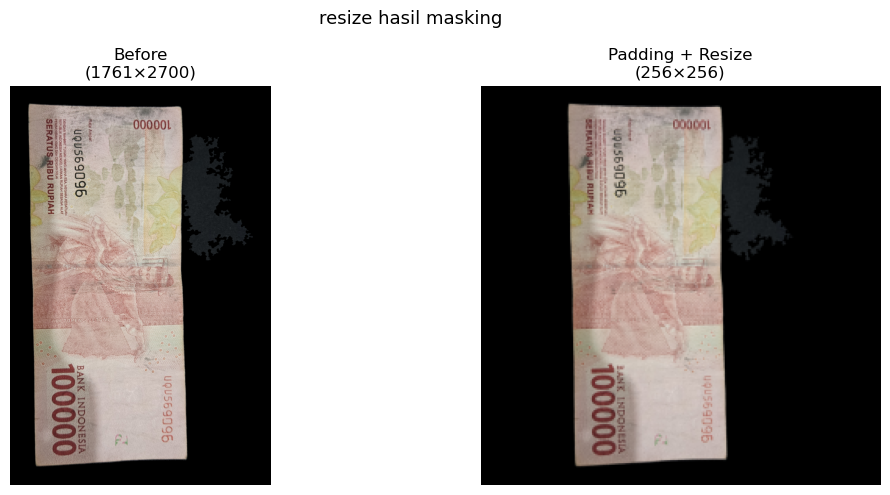

In [273]:
resized = resize(
    cropped,
    TARGET_WIDTH,
    TARGET_HEIGHT
)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
axes[0].set_title(
    f"Before\n({cropped.shape[1]}×{cropped.shape[0]})"
)

axes[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f"Padding + Resize\n({TARGET_WIDTH}×{TARGET_HEIGHT})"
)

for ax in axes:
    ax.axis("off")

plt.suptitle("resize hasil masking", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Normalization

Tipe data  : float32
Nilai min  : 0.0000
Nilai max  : 0.8784
Shape      : (256, 256, 3)


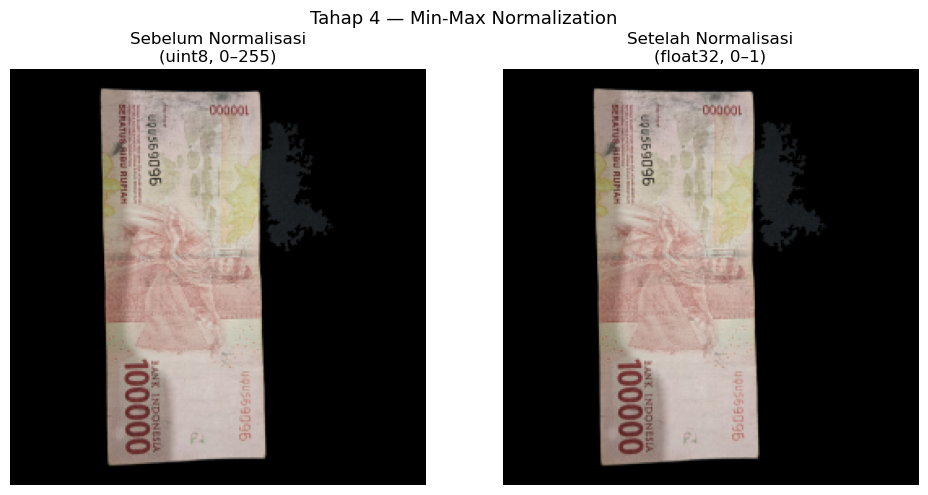

In [274]:
def normalize_minmax(image_bgr):
    return image_bgr.astype(np.float32) / 255.0

normed = normalize_minmax(resized)

print(f"Tipe data  : {normed.dtype}")
print(f"Nilai min  : {normed.min():.4f}")
print(f"Nilai max  : {normed.max():.4f}")
print(f"Shape      : {normed.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Sebelum Normalisasi\n(uint8, 0–255)")
axes[1].imshow(cv2.cvtColor(normed, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Normalisasi\n(float32, 0–1)")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 4 — Min-Max Normalization", fontsize=13)
plt.tight_layout()
plt.show()